In [1]:
%matplotlib inline
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.spectrum import log_bins, bin_midpoints, spectrum_from_function, normalise, maxwellian_pdf
from src.example_fields import inverse_energy_pdf
from src.dose import load_coefficients
from src.uncertainty import sample_spectra
from src.compare import compare_spectra, group_ratios, group_z_scores, dose_ratio_distribution

In [2]:
energies, coeffs = load_coefficients()
edges = log_bins(1e-3, 20.0, 400)
mid = bin_midpoints(edges)
T = 1.42   # MeV; check against ISO 8529 before citing as a reference value

phi_ref = normalise(spectrum_from_function(edges, maxwellian_pdf, T))

def measured_pdf(E, scatter_fraction=0.15):
    """Maxwellian with 15% of neutrons moved to a low-energy 1/E component."""
    return ((1 - scatter_fraction) * maxwellian_pdf(E, T)
            + scatter_fraction * inverse_energy_pdf(E, 1e-3, 0.5))

phi_meas = normalise(spectrum_from_function(edges, measured_pdf))

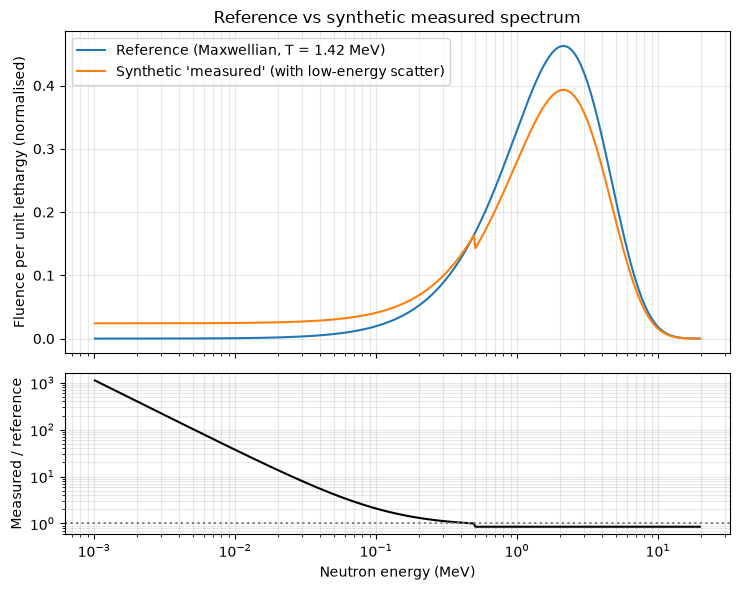

In [3]:
dln = np.log(edges[1:] / edges[:-1])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1.5]})
ax1.semilogx(mid, phi_ref / dln, label="Reference (Maxwellian, T = 1.42 MeV)")
ax1.semilogx(mid, phi_meas / dln, label="Synthetic 'measured' (with low-energy scatter)")
ax1.set_ylabel("Fluence per unit lethargy (normalised)")
ax1.set_title("Reference vs synthetic measured spectrum")
ax1.legend()
ax1.grid(alpha=0.3, which="both")

ax2.loglog(mid, phi_meas / phi_ref, "k-")
ax2.axhline(1, color="grey", linestyle=":")
ax2.set_xlabel("Neutron energy (MeV)")
ax2.set_ylabel("Measured / reference")
ax2.grid(alpha=0.3, which="both")

fig.tight_layout()
fig.savefig("../figures/spectrum_comparison.png", dpi=300)
plt.show()

In [4]:
comp = compare_spectra(edges, phi_ref, phi_meas, energies, coeffs)
pd.Series(comp).round(3)

fluence_ratio               1.000
mean_energy_ref_MeV         2.130
mean_energy_test_MeV        1.823
dose_ratio                  0.875
avg_coeff_ref_pSv_cm2     383.192
avg_coeff_test_pSv_cm2    335.467
avg_coeff_ratio             0.875
dose_ratio_epithermal       4.201
dose_ratio_fast             0.869
dtype: float64

In [5]:
group_edges = log_bins(1e-3, 20.0, 8)
ratios = group_ratios(edges, phi_ref, phi_meas, group_edges)
labels = [f"{group_edges[i]:.3g}-{group_edges[i+1]:.3g}" for i in range(len(ratios))]
pd.DataFrame({"group (MeV)": labels, "shape ratio (measured/reference)": ratios}).round(2)

,group (MeV),shape ratio (measured/reference)
0,0.001-0.00345,394.79
1,0.00345-0.0119,62.61
2,0.0119-0.041,10.63
3,0.041-0.141,2.45
4,0.141-0.488,1.14
5,0.488-1.68,0.85
6,1.68-5.8,0.85
7,5.8-20,0.85


In [6]:
samples = sample_spectra(phi_meas, 0.05, 0.03, n=10000, seed=1)   # assumed uncertainties
z = group_z_scores(edges, phi_ref, samples, group_edges)
pd.DataFrame({"group (MeV)": labels, "z-score": z}).round(1)

,group (MeV),z-score
0,0.001-0.00345,32.4
1,0.00345-0.0119,32.1
2,0.0119-0.041,29.4
3,0.041-0.141,19.2
4,0.141-0.488,4.1
5,0.488-1.68,-5.7
6,1.68-5.8,-5.7
7,5.8-20,-5.5


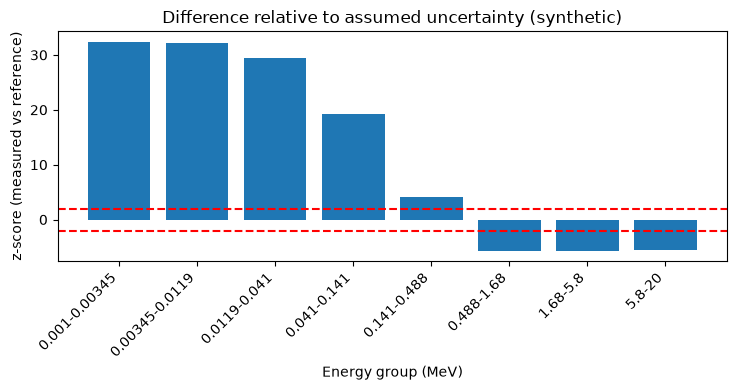

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(range(len(z)), z)
ax.set_xticks(range(len(z)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.axhline(2, color="r", linestyle="--")
ax.axhline(-2, color="r", linestyle="--")
ax.set_xlabel("Energy group (MeV)")
ax.set_ylabel("z-score (measured vs reference)")
ax.set_title("Difference relative to assumed uncertainty (synthetic)")
fig.tight_layout()
fig.savefig("../figures/group_z_scores.png", dpi=300)
plt.show()

Dose ratio: mean 0.875, 95% interval [0.824, 0.927]
Consistent with 1.0 (no difference)? False


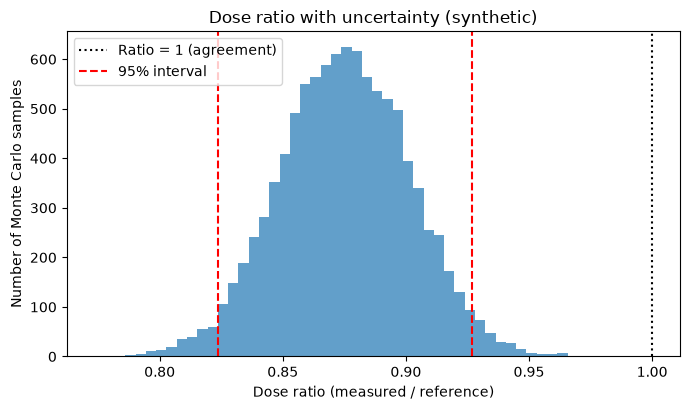

In [8]:
dr = dose_ratio_distribution(edges, phi_ref, samples, energies, coeffs)
lo, hi = np.percentile(dr, [2.5, 97.5])
print(f"Dose ratio: mean {dr.mean():.3f}, 95% interval [{lo:.3f}, {hi:.3f}]")
print("Consistent with 1.0 (no difference)?", lo <= 1.0 <= hi)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(dr, bins=50, alpha=0.7)
ax.axvline(1.0, color="k", linestyle=":", label="Ratio = 1 (agreement)")
ax.axvline(lo, color="r", linestyle="--", label="95% interval")
ax.axvline(hi, color="r", linestyle="--")
ax.set_xlabel("Dose ratio (measured / reference)")
ax.set_ylabel("Number of Monte Carlo samples")
ax.set_title("Dose ratio with uncertainty (synthetic)")
ax.legend()
fig.tight_layout()
fig.savefig("../figures/dose_ratio_distribution.png", dpi=300)
plt.show()